In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
df=pd.read_csv("bang.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [4]:
df=df.drop(['area_type','society','balcony','availability'],axis='columns')
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [5]:
df.isna().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [6]:
df=df.dropna()

In [7]:
df.isna().sum(axis=0)

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [8]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [9]:
df['bhk']=df['size'].apply(lambda x:int(x.split(' ')[0]))
df

C:\Users\BIT\AppData\Local\Temp\ipykernel_25692\2250118193.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bhk']=df['size'].apply(lambda x:int(x.split(' ')[0]))


,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00,5
13316,Richards Town,4 BHK,3600,5.0,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00,4


In [10]:
df=df.drop(['size'],axis='columns')
df

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056,2.0,39.07,2
1,Chikka Tirupathi,2600,5.0,120.00,4
2,Uttarahalli,1440,2.0,62.00,3
3,Lingadheeranahalli,1521,3.0,95.00,3
4,Kothanur,1200,2.0,51.00,2
...,...,...,...,...,...
13315,Whitefield,3453,4.0,231.00,5
13316,Richards Town,3600,5.0,400.00,4
13317,Raja Rajeshwari Nagar,1141,2.0,60.00,2
13318,Padmanabhanagar,4689,4.0,488.00,4


In [11]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True    

In [12]:
df[~df['total_sqft'].apply(is_float)].count()

location      190
total_sqft    190
bath          190
price         190
bhk           190
dtype: int64

In [13]:
df[~df['total_sqft'].apply(is_float)].head(10)

,location,total_sqft,bath,price,bhk
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [14]:
def convert(x):
    tokens=x.split("-")
    if len(tokens)==2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None


In [15]:
cln=df.copy()
cln.total_sqft=cln.total_sqft.apply(convert)
cln.head(10)

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
5,Whitefield,1170.0,2.0,38.00,2
6,Old Airport Road,2732.0,4.0,204.00,4
7,Rajaji Nagar,3300.0,4.0,600.00,4
8,Marathahalli,1310.0,3.0,63.25,3
9,Gandhi Bazar,1020.0,6.0,370.00,6


In [16]:
cln.isna().sum()

location       0
total_sqft    46
bath           0
price          0
bhk            0
dtype: int64

## `inplace` in `dropna()`

### `inplace=False` (default)

```python
df2 = df.dropna()
```

- Creates a new DataFrame
- Original `df` remains unchanged
- Returns the new DataFrame

### `inplace=True`

```python
df.dropna(inplace=True)
```

- Modifies the original `df`
- No new DataFrame is created
- Returns `None`

### Summary

| Value | Original `df` Modified? | Returns New DataFrame? |
|---------|---------|---------|
| `False` | ❌ No | ✅ Yes |
| `True` | ✅ Yes | ❌ No (`None`) |

In [17]:
cln.dropna(inplace=True)

In [18]:
cln

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5
13316,Richards Town,3600.0,5.0,400.00,4
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2
13318,Padmanabhanagar,4689.0,4.0,488.00,4


In [19]:
cln.isna().sum()

location      0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64

In [22]:
cln

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5
13316,Richards Town,3600.0,5.0,400.00,4
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2
13318,Padmanabhanagar,4689.0,4.0,488.00,4


## FEATURE ENGINEERING

In [30]:
cln_f=cln.copy()
cln_f['price_per_sqft']=cln_f['price']*100000/cln_f['total_sqft']



In [31]:
cln_f

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5,6689.834926
13316,Richards Town,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4689.0,4.0,488.00,4,10407.336319


In [32]:
cln_f.rename(columns={'price': 'price(in lakh)'}, inplace=True)
cln_f

,location,total_sqft,bath,price(in lakh),bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5,6689.834926
13316,Richards Town,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4689.0,4.0,488.00,4,10407.336319


In [33]:
cln_f.to_csv("bng_hs_pr.csv",index=False)

In [35]:
cln_f['location']=cln_f['location'].apply(lambda x:x.strip())
location_stat=cln_f['location'].value_counts(ascending=False)
location_stat

location
Whitefield                           533
Sarjapur  Road                       392
Electronic City                      304
Kanakpura Road                       264
Thanisandra                          235
                                    ... 
Zuzuvadi                               1
Chellikere                             1
Jakkasandra                            1
Gulakamale                             1
Beml layout, Rajarajeshwari nagar      1
Name: count, Length: 1287, dtype: int64

In [36]:
location_stats_gr_10 = location_stat[location_stat > 10]
cln_f['location']=cln_f['location'].apply(lambda x: x if x in location_stats_gr_10 else 'others')
cln_f

,location,total_sqft,bath,price(in lakh),bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5,6689.834926
13316,others,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4689.0,4.0,488.00,4,10407.336319


In [40]:
len(location_stats_gr_10.unique())

79

In [ ]:

cln_f.shape

(13200, 6)

## Outliers removal
### Ambiguos data 
there can be some ***ambiguity*** in the data.

***remove the data rows whose size per bedroom is less than 300 sqft***

In [67]:
dataf=cln_f[cln_f['total_sqft']/cln_f['bhk']>300]
print(dataf)
print(dataf.shape)

                       location  total_sqft  bath  price(in lakh)  bhk  \
0      Electronic City Phase II      1056.0   2.0           39.07    2   
1              Chikka Tirupathi      2600.0   5.0          120.00    4   
2                   Uttarahalli      1440.0   2.0           62.00    3   
3            Lingadheeranahalli      1521.0   3.0           95.00    3   
4                      Kothanur      1200.0   2.0           51.00    2   
...                         ...         ...   ...             ...  ...   
13315                Whitefield      3453.0   4.0          231.00    5   
13316                    others      3600.0   5.0          400.00    4   
13317     Raja Rajeshwari Nagar      1141.0   2.0           60.00    2   
13318           Padmanabhanagar      4689.0   4.0          488.00    4   
13319              Doddathoguru       550.0   1.0           17.00    1   

       price_per_sqft  
0         3699.810606  
1         4615.384615  
2         4305.555556  
3         6245.

In [68]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    plt.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2['price_per_sqft'],color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft,bhk3['price_per_sqft'],marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    


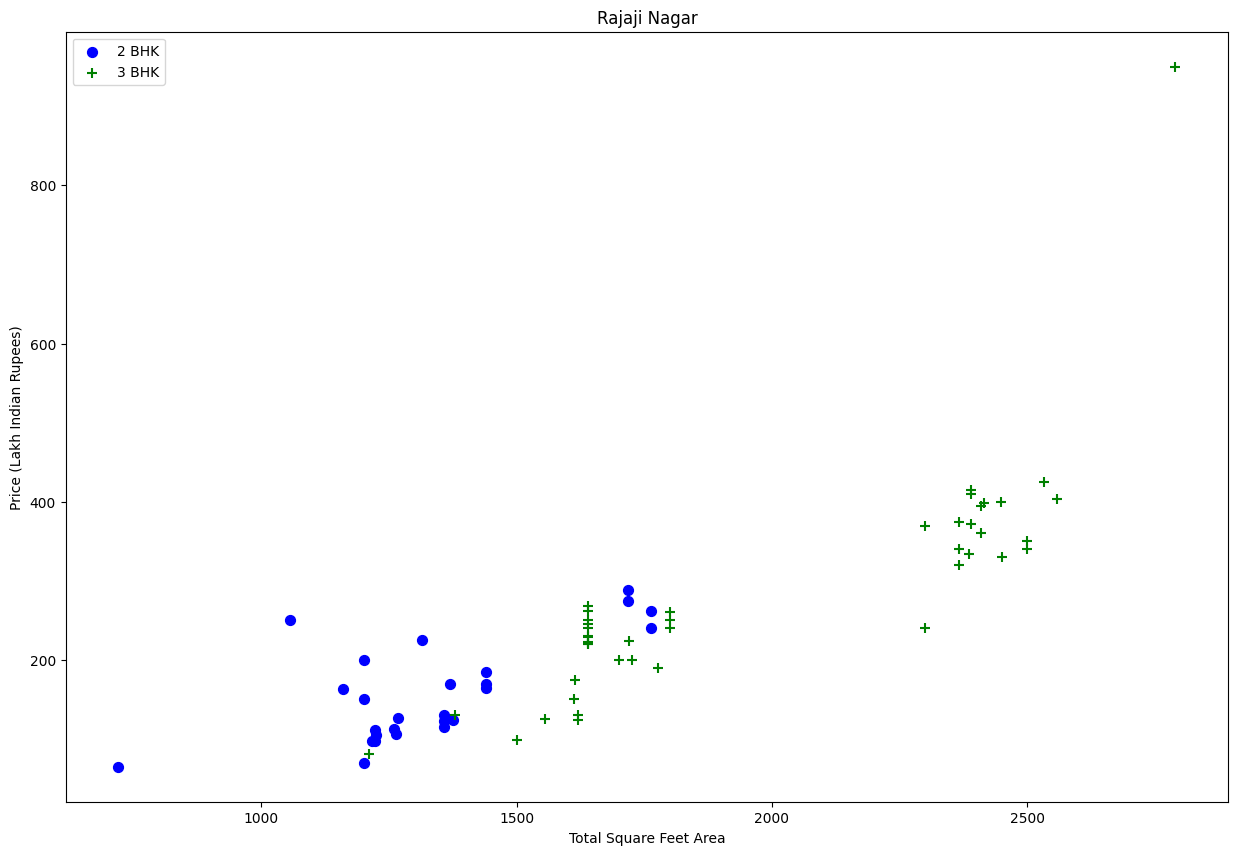

In [55]:
plot_scatter_chart(dataf,'Rajaji Nagar')

In [69]:
dataf['bhk'].value_counts()

bhk
2     5449
3     4719
4     1106
1      634
5      193
6       85
7       41
8       22
9       15
10       6
11       2
16       1
13       1
Name: count, dtype: int64

In [147]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
print(dataf.shape)
dataf=remove_pps_outliers(dataf)
print(dataf.shape)


(12274, 6)
(10018, 6)


In [148]:
def outlier_removal(df):
    rmv_idx=[]
    for locat,loc_df in df.groupby('location'):
     bhk_stats={}
     for bhk,bhk_df in loc_df.groupby('bhk'):
        bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
     for bhk,bhk_df in loc_df.groupby('bhk'):
        stat=bhk_stats.get(bhk-1)
        if stat and stat['count']>5:
           threshold=stat['mean']
           outlier=bhk_df[bhk_df['price_per_sqft']<threshold]
           rmv_idx.extend(outlier.index)

    return df.drop(rmv_idx,axis='index')


In [149]:
print(dataf.shape)
data_cln=outlier_removal(dataf)
print(data_cln.shape)

(10018, 6)
(7150, 6)


In [150]:
print(f"size of data_cln ={data_cln.shape}")
dataf_full_cln=data_cln[data_cln['bhk']+2>data_cln['bath']]
print(f"size of data_full_cln ={dataf_full_cln.shape}")

size of data_cln =(7150, 6)
size of data_full_cln =(7074, 6)


In [151]:
dummies = pd.get_dummies(dataf_full_cln.location)
dummies.head(20)

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,others
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [152]:
dummies=dummies.drop(['others'],axis=1)

In [153]:
final=pd.concat([dataf_full_cln,dummies],axis=1)
final

,location,total_sqft,bath,price(in lakh),bhk,price_per_sqft,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,15017.543860,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,194.0,3,11901.840491,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,235.0,3,12533.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,130.0,3,10833.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,148.0,2,11983.805668,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10009,others,1200.0,2.0,70.0,2,5833.333333,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10010,others,1800.0,1.0,200.0,1,11111.111111,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10013,others,1353.0,2.0,110.0,2,8130.081301,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10014,others,812.0,1.0,26.0,1,3201.970443,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [154]:
print(final.shape)
final=final.drop(['location','price_per_sqft'],axis=1)

print(final.shape)

(7074, 246)
(7074, 244)


In [155]:
input=final.drop(['price(in lakh)'],axis=1)
input

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10009,1200.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10010,1800.0,1.0,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10013,1353.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10014,812.0,1.0,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [156]:
output=final['price(in lakh)']
output

0        428.0
1        194.0
2        235.0
3        130.0
4        148.0
         ...  
10009     70.0
10010    200.0
10013    110.0
10014     26.0
10017    400.0
Name: price(in lakh), Length: 7074, dtype: float64

In [157]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input,output,test_size=0.2)

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
result={}

def find_best_model_using_gridsearchcv(X,y):
    algos = {
    'linear_regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'lasso': {
        'model': Lasso(max_iter=1000),
        'params': {
            'alpha': [1, 2],
            'selection': ['random', 'cyclic']
        }
    },
    'decision_tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'criterion': ['squared_error', 'friedman_mse'],
            'splitter': ['best', 'random']
        }
    },
    'gradient_boosting':{
        'model': GradientBoostingRegressor(),
        'params':{
          'n_estimators': [100, 200],
          'learning_rate': [0.01, 0.05, 0.1],
          'max_depth': [3, 5]
         }
        
    }
}
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'],config['params'], cv=cv, return_train_score=False, n_jobs=-1)
        gs.fit(X,y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

In [159]:
find_best_model_using_gridsearchcv(input,output)#1st time with random state 10;

,model,best_score,best_params
0,linear_regression,0.838379,{}
1,lasso,0.695563,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.770973,"{'criterion': 'squared_error', 'splitter': 'random'}"
3,gradient_boosting,0.745388,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}"


In [160]:
result=find_best_model_using_gridsearchcv(input,output)

In [161]:
result

,model,best_score,best_params
0,linear_regression,0.838379,{}
1,lasso,0.695563,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.694244,"{'criterion': 'squared_error', 'splitter': 'random'}"
3,gradient_boosting,0.744489,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}"


In [ ]:
pd.set_option('display.max_colwidth', None)# to set full width of column , so that it does not truncate any important value
result

,model,best_score,best_params
0,linear_regression,0.608765,{}
1,lasso,0.557736,"{'alpha': 2, 'selection': 'cyclic'}"
2,decision_tree,0.510682,"{'criterion': 'squared_error', 'splitter': 'best'}"
3,gradient_boosting,0.691991,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}"


In [162]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [163]:
model.score(x_test,y_test)

0.793555061009638

In [164]:
def predictor(loc,sqft,bath,bhk):
    x=np.zeros(input.shape[1])
    x[0]=sqft
    x[1]=bath
    x[2]=bhk
    loc_index = np.where(input.columns == loc)[0]

    if len(loc_index) > 0:
     x[loc_index[0]] = 1

    return x 

In [165]:
model.predict([predictor('1st Phase JP Nagar',1000, 2, 2)])

C:\Users\BIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([91.88323265])

In [166]:
model.predict([predictor('Indira Nagar',1000, 3, 3)])

C:\Users\BIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([180.0904648])

In [167]:
import pickle
with open("bangalore_home_price.pickle",'wb') as f:
    pickle.dump(model,f)

In [ ]:
import json

columns = {
    'data_columns' : [col.lower() for col in input.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))

In [169]:
# After training your model
 
columns = input.columns.tolist()  # or df.columns

# Save together
model_data = {
    'model': model,
    'columns': columns
}

with open('model_column.pickle', 'wb') as f:
    pickle.dump(model_data, f)